In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, FunctionTransformer,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [2]:
original_df=pd.read_csv("clients_data_final_recommender_model.csv")

In [3]:
df=original_df.drop("jobma_catcher_id", axis=1)

In [4]:
df

,company_size,currency,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken
0,1-25,1,0,1,1,1.0,66666.0,1,0,15000.00,1,4.0,2.0,1.0,1.0
1,26-100,1,0,2,1,0.0,60.0,0,1,53.10,1,0.0,0.0,0.0,0.0
2,101-500,1,0,2,1,0.0,60.0,0,1,118.00,1,0.0,0.0,0.0,0.0
3,26-100,1,0,1,1,0.0,50.0,0,1,15200.18,3,0.0,0.0,1.0,0.0
4,26-100,1,0,2,1,0.0,60.0,0,1,11800.00,1,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4456,1-25,0,0,1,1,0.0,35.0,0,0,100.00,1,3.0,1.0,2.0,3.0
4457,1-25,0,0,1,1,0.0,147.0,0,0,0.00,1,3.0,3.0,5.0,1.0
4458,26-100,0,0,1,1,0.0,50.0,0,0,100.00,1,0.0,0.0,0.0,0.0
4459,1-25,0,0,1,1,0.0,49.0,0,0,0.00,1,2.0,2.0,2.0,1.0


In [5]:
df.shape

(4461, 15)

In [6]:
df.nunique()

company_size                 5
currency                     2
is_premium                   2
subscription_status          2
jobma_catcher_status         2
sub_users                   19
wallet_amount              179
is_unlimited                 2
plan_type                    2
subscription_sum           784
subscription_count          34
invitations                126
pre_recorded_kit_counts     57
number_of_jobs_posted       51
pre_rec_interview_taken     89
dtype: int64

In [7]:
binary_columns = ['is_premium',
                  'currency',
                  'subscription_status',
                  'jobma_catcher_status',
                  'is_unlimited',
                  'plan_type',
                 ]

categorical_columns = ['company_size']
                   
numerical_columns= ['sub_users',
                    'wallet_amount',
                    'subscription_count',
                    'invitations',
                    'pre_recorded_kit_counts',
                    'number_of_jobs_posted',
                    'pre_rec_interview_taken']

ordinal_columns =['subscription_sum']

In [8]:
# Clean binary values , # Remove negatives and  clamp to 0
def log_transform(X):
    X = X.copy()
    X[X <= 0] = 1e-10
    return np.log(X)

def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_numerical(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce'))

def clean_ordinal(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce')).clip(lower=0)
    

In [9]:
# Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(lambda x: np.log1p(x), validate=False)),
                                  ])

numerical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_numerical, validate=False)),
                                     ('imputer', SimpleImputer(strategy='mean')),
                                    ])

preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns), 
                                               ('ord', ordinal_pipeline, ordinal_columns),
                                               ('num', numerical_pipeline, numerical_columns),
                                              ])

# Final pipeline
pipeline = Pipeline([('preprocessing', preprocessor),
                    ('scaler', StandardScaler())])

In [10]:
pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('bin',
                                                  Pipeline(steps=[('cleaner',
                                                                   FunctionTransformer(func=<function clean_binary at 0x0000028811594D30>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['is_premium', 'currency',
                                                   'subscription_status',
                                                   'jobma_catcher_status',
                                                   'is_unlimited',
                                                   'plan_type']),
                                                 ('cat',
                                                  Pipeline(steps=[('cle...
                                                                   FunctionTransformer(func=<function <lambda> at 0x0000028811595120>))]),
                                                  ['subscription_sum']),
                                                 ('num',
                                                  Pipeline(steps=[('cleaner',
                                                                   FunctionTransformer(func=<function clean_numerical at 0x0000028811594E50>)),
                                                                  ('imputer',
                                                                   SimpleImputer())]),
                                                  ['sub_users', 'wallet_amount',
                                                   'subscription_count',
                                                   'invitations',
                                                   'pre_recorded_kit_counts',
                                                   'number_of_jobs_posted',
                                                   'pre_rec_interview_taken'])])),
                ('scaler', StandardScaler())])

In [11]:
df.shape

(4461, 15)

In [12]:
X = pipeline.fit_transform(df)
X_tensor = torch.tensor(X, dtype=torch.float32)
X_tensor.shape

torch.Size([4461, 19])

In [13]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        embeddings = self.encoder(x)
        reconstructed = self.decoder(embeddings)
        return reconstructed, embeddings

In [14]:
input_dim = X_tensor.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 40
batch_size = 16

In [15]:
loss_history = []
test_loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(0, len(X_tensor), batch_size):
        x_batch = X_tensor[i:i + batch_size]

        optimizer.zero_grad()
        reconstructed, _ = model(x_batch)
        
        loss = criterion(reconstructed, x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(X_tensor) / batch_size)
    loss_history.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 5/40, Loss: 0.0570
Epoch 10/40, Loss: 0.0454
Epoch 15/40, Loss: 0.0294
Epoch 20/40, Loss: 0.0283
Epoch 25/40, Loss: 0.0202
Epoch 30/40, Loss: 0.0165
Epoch 35/40, Loss: 0.0164
Epoch 40/40, Loss: 0.0173


In [16]:
#Extract embeddings and # Convert embeddings to numpy array
with torch.no_grad():
    _, embeddings = model(X_tensor)
embeddings_np = embeddings.numpy()
embeddings_np.shape

(4461, 32)

In [17]:
type(embeddings_np), embeddings.shape

(numpy.ndarray, torch.Size([4461, 32]))

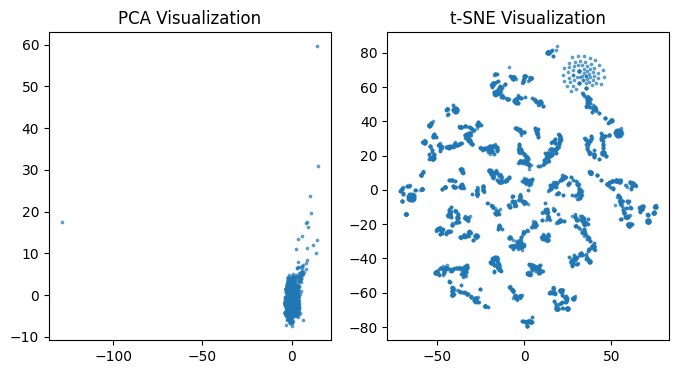

In [18]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_np)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(embeddings_np)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=3, alpha=0.6)
plt.title('PCA Visualization')
plt.subplot(1, 2, 2)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=3, alpha=0.6)
plt.title('t-SNE Visualization')
plt.show()

In [35]:
#Recommend top N candidates based on cosine similarity. #cosine similarity # Sort by similarit
def recommend_client(query_index, embedings, top_n=5):
    similarities = cosine_similarity([embeddings[query_index]], embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_n]

    print(f"\nTop {top_n} similar clients as index {query_index}:")
    for i, idx in enumerate(top_indices):
        print(f"{i+1}. Client {idx} - Similarity: {similarities[idx]:.4f}")

recommend_client(0, embeddings_np, top_n=10)


Top 10 similar clients as index 0:
1. Client 0 - Similarity: 1.0000
2. Client 1834 - Similarity: 0.9604
3. Client 1275 - Similarity: 0.9546
4. Client 1954 - Similarity: 0.8903
5. Client 3265 - Similarity: 0.8837
6. Client 1571 - Similarity: 0.8830
7. Client 1964 - Similarity: 0.8785
8. Client 2897 - Similarity: 0.8770
9. Client 3739 - Similarity: 0.8770
10. Client 3342 - Similarity: 0.8770


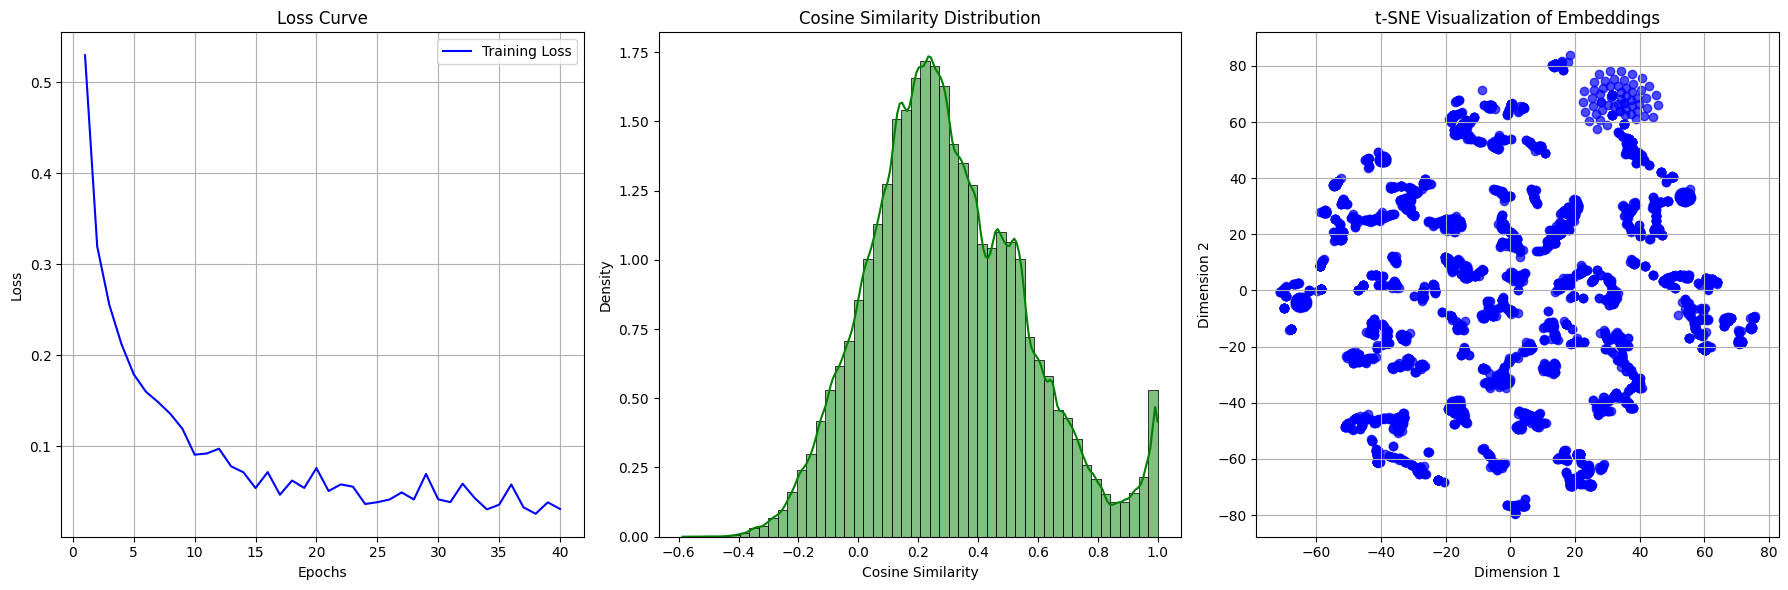

In [20]:

# 1. Plotting the Loss Curve  # 2. Cosine Similarity Distribution  # 3. t-SNE Visualization
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].plot(range(1, epochs + 1), loss_history, label='Training Loss', color='blue')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_title('Loss Curve')
axs[0].grid(True)
axs[0].legend()

similarities = cosine_similarity(embeddings_np)
sim_scores = similarities[np.triu_indices_from(similarities, k=1)]
sns.histplot(sim_scores, bins=50, kde=True, color='green', stat='density', ax=axs[1])
axs[1].set_title('Cosine Similarity Distribution')
axs[1].set_xlabel('Cosine Similarity')
axs[1].set_ylabel('Density')

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_np)
axs[2].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='blue', alpha=0.7)
axs[2].set_title('t-SNE Visualization of Embeddings')
axs[2].set_xlabel('Dimension 1')
axs[2].set_ylabel('Dimension 2')
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [21]:
df.columns

Index(['company_size', 'currency', 'is_premium', 'subscription_status',
       'jobma_catcher_status', 'sub_users', 'wallet_amount', 'is_unlimited',
       'plan_type', 'subscription_sum', 'subscription_count', 'invitations',
       'pre_recorded_kit_counts', 'number_of_jobs_posted',
       'pre_rec_interview_taken'],
      dtype='object')

In [22]:
def recommend_from_sample_dict(sample_dict, full_embeddings, original_df, pipeline, model, top_n=5):
    sample_df = pd.DataFrame([sample_dict])
    transformed = pipeline.transform(sample_df)
    sample_tensor = torch.tensor(transformed, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        _, sample_embedding = model(sample_tensor)
    similarities = cosine_similarity(sample_embedding, full_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][2:top_n+2]
    result_df = original_df.iloc[top_indices].copy()
    result_df['similarity_score'] = similarities[top_indices]
    result_df.reset_index(drop=True, inplace=True)
    return result_df

In [23]:
sample_dict = { 'company_size': '1-25',
                'currency': 1,
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 1,
                'wallet_amount': 60,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_sum': 150,
                'subscription_count': 1,
                'invitations': 1,
                'pre_recorded_kit_counts': 0.0,
                'number_of_jobs_posted': 0.0,
                'pre_rec_interview_taken': 0.0,}

In [24]:
recommend_from_sample_dict(sample_dict, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,currency,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,similarity_score
0,4150,1-25,1,0,2,1,1.0,60.0,0,1,129.8,2,0.0,0.0,0.0,0.0,0.943375
1,3027,1-25,1,0,2,1,1.0,60.0,0,1,23.6,1,0.0,0.0,0.0,0.0,0.918425
2,3742,1-25,1,0,2,1,1.0,60.0,0,1,1180.0,2,0.0,0.0,0.0,0.0,0.918081
3,3384,1-25,1,0,2,1,1.0,60.0,0,1,1113.6,2,5.0,1.0,1.0,0.0,0.914643
4,3324,1-25,1,0,2,1,1.0,60.0,0,1,1180.0,1,1.0,2.0,2.0,0.0,0.908307


In [25]:
sample_dict2 = { 'company_size': '26-100',
                'currency': 1,
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 1,
                'wallet_amount': 50,
                'is_unlimited': 0,
                'plan_type': 0,
                'subscription_sum': 1000,
                'subscription_count': 2,
                'invitations': 2,
                'pre_recorded_kit_counts': 1,
                'number_of_jobs_posted': 5,
                'pre_rec_interview_taken': 9,}

In [26]:
recommend_from_sample_dict(sample_dict2, embeddings_np, original_df, pipeline, model, top_n=10)

,jobma_catcher_id,company_size,currency,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,similarity_score
0,6353,26-100,1,0,2,1,0.0,60.0,0,0,99.0,1,0.0,0.0,0.0,0.0,0.911221
1,5570,26-100,1,0,2,1,0.0,60.0,0,0,15000.0,1,0.0,0.0,0.0,0.0,0.885555
2,5479,26-100,1,0,2,1,0.0,60.0,0,0,15000.0,1,0.0,0.0,0.0,0.0,0.885555
3,5480,26-100,1,0,2,1,0.0,60.0,0,0,15000.0,1,0.0,0.0,0.0,0.0,0.885555
4,5596,26-100,1,0,2,1,0.0,60.0,0,0,25000.0,1,0.0,0.0,0.0,0.0,0.866405
5,5490,26-100,1,0,2,1,0.0,60.0,0,0,25000.0,1,0.0,0.0,0.0,0.0,0.866405
6,5568,26-100,1,0,2,1,0.0,60.0,0,0,32700.0,2,0.0,0.0,0.0,0.0,0.856341
7,4391,26-100,1,0,1,1,0.0,60.0,1,0,1000.0,1,5.0,1.0,1.0,1.0,0.793017
8,4868,26-100,1,0,2,1,0.0,60.0,1,0,1000.0,1,0.0,0.0,0.0,0.0,0.786757
9,4713,26-100,1,0,2,1,0.0,60.0,1,0,1000.0,1,0.0,0.0,0.0,0.0,0.786757


In [27]:
sample_dict4 = { 'company_size': '101-500',
                'currency': 1,
                'is_premium': 1,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 10,
                'wallet_amount': 50,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_sum': 47200,
                'subscription_count': 7,
                'invitations': 5,
                'pre_recorded_kit_counts': 6,
                'number_of_jobs_posted': 5,
                'pre_rec_interview_taken': 12,}

In [28]:
recommend_from_sample_dict(sample_dict4, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,currency,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,similarity_score
0,5722,101-500,1,1,2,1,5.0,60.0,0,1,17700.0,1,5.0,2.0,1.0,2.0,0.934833
1,5416,101-500,1,0,2,1,9.0,60.0,0,1,29500.0,1,12.0,1.0,1.0,1.0,0.922973
2,4718,101-500,1,1,1,1,4.0,60.0,0,1,2960.5,5,0.0,0.0,0.0,0.0,0.915909
3,7979,101-500,1,0,2,1,3.0,60.0,0,1,25000.0,4,0.0,0.0,0.0,0.0,0.848727
4,5429,101-500,1,1,2,1,2.0,60.0,0,1,17700.0,1,4.0,1.0,1.0,0.0,0.844168


In [29]:
sample_dict5  = {'company_size': '1-25',
                 'currency': 0,
                 'is_premium': 1,
                 'subscription_status': 1,
                 'jobma_catcher_status': 1,
                 'sub_users': 55.0,
                 'wallet_amount': 3053.0,
                 'is_unlimited': 0,
                 'plan_type': 0,
                 'subscription_sum': 47200.0,
                 'subscription_count': 4,
                 'invitations': 518.0,
                 'pre_recorded_kit_counts': 292.0,
                 'number_of_jobs_posted': 181.0,
                 'pre_rec_interview_taken': 135.0}

In [30]:
recommend_from_sample_dict(sample_dict5, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,currency,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,similarity_score
0,5335,500-1000,0,1,1,0,17.0,60.0,0,0,27886.0,11,519.0,71.0,89.0,203.0,0.763058
1,9377,More than 1000,0,1,1,1,10.0,15.0,0,0,50.0,1,59.0,114.0,6.0,38.0,0.742376
2,9579,1-25,0,1,1,1,24.0,2181.0,0,0,350.0,4,1465.0,116.0,179.0,441.0,0.740785
3,8329,1-25,1,0,2,1,9.0,60.0,0,1,25000.0,1,184.0,11.0,19.0,74.0,0.737810
4,6227,500-1000,1,1,2,1,11.0,60.0,0,1,59000.0,2,96.0,19.0,14.0,54.0,0.703942
